In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')   

In [4]:
matplotlib.rcParams['font.family'] ='AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] =False

# sns.set(font="Malgun Gothic", 
#         rc={"axes.unicode_minus":False},)

In [5]:
all = pd.read_csv('./data/jinju.csv', index_col=0)
print(all.shape)
all.head(2)

(13207, 22)


,시군구,번지,도로조건,계약면적(㎡),계약년월,계약일,보증금(만원),월세(만원),건축년도,도로명,...,year,month,location,전월세전환율,전세전환가격,coivd,price_per_m2,gnu_distance,전월세구분_월세,전월세구분_전세
0,경상남도 진주시 가좌동,1***,25,12.0,201902,16,200,35,2016,가좌길74번길,...,2019,2,경상남도 진주시 가좌동 가좌길74번길,5.1,8435,0,702.916667,0.657356,True,False
1,경상남도 진주시 가좌동,1***,8,12.0,201901,5,4500,0,2016,가좌길78번길,...,2019,1,경상남도 진주시 가좌동 가좌길78번길,5.3,4500,0,375.000000,0.657356,False,True


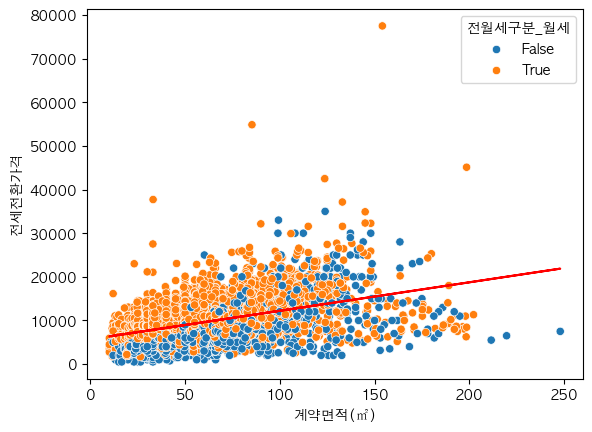

In [6]:
sns.scatterplot(data = all, x = "계약면적(㎡)", y = "전세전환가격", hue = "전월세구분_월세")
# sns.lmplot(data = all, x = "계약면적(㎡)", y = "전세전환가격")
m, b = np.polyfit(all["계약면적(㎡)"] , all["전세전환가격"], 1)
plt.plot(all["계약면적(㎡)"], m * all["계약면적(㎡)"] + b, color = "red")
plt.show()

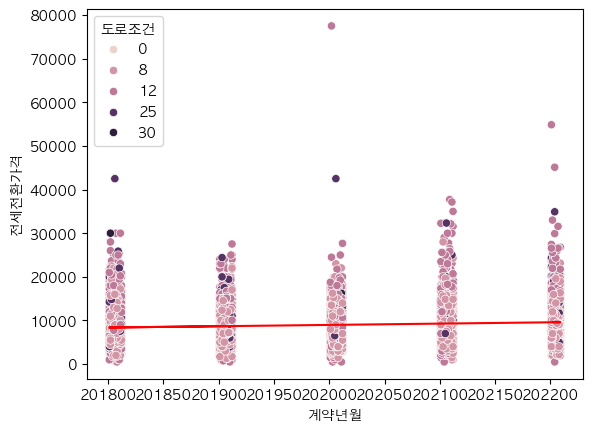

In [7]:
sns.scatterplot(data = all, x = "계약년월", y = "전세전환가격", hue = "도로조건")
m, b = np.polyfit(all["계약년월"] , all["전세전환가격"], 1)
plt.plot(all["계약년월"], m * all["계약년월"] + b, color = "red")
plt.show()

In [8]:
# area = []

# for long, lat in zip(all["경도"],all["위도"]) :
#     if 128.102554 < long < 128.107094 and 35.155823 < lat < 35.162156 :
#         area.append('후문')
#     elif 128.107502 < long < 128.116019 and 35.155877 < lat < 35.158884 :
#         area.append('경찰서')
#     elif 128.105510 < long < 128.109887 and 35.152340 < lat <35.155835 :
#         area.append('정문')
#     elif 128.099328 < long < 128.105970 and 35.14718 < lat < 35.151686 :
#         area.append('남문')
#     elif 128.102356 < long < 128.118509 and 35.161807 < lat < 35.166844 :
#         area.append('호탄')
#     elif 128.107524 < long < 128.118378 and 35.159442 < lat < 35.161644 :
#         area.append('호탄')
#     else :
#         area.append('그 외')

# all["area"] = area
# all

In [9]:
import math as m

def distance(x1, x2, y1, y2):
    radius = 6371 # 지구 반지름(km)
    toRadian = m.pi / 180

    deltaLatitude = abs(x1 - x2) * toRadian
    deltaLongitude = abs(y1 - y2) * toRadian

    sinDeltaLat = m.sin(deltaLatitude / 2)
    sinDeltaLng = m.sin(deltaLongitude / 2)
    squareRoot = m.sqrt(sinDeltaLat * sinDeltaLat + m.cos(x1 * toRadian) * m.cos(x2 * toRadian) * sinDeltaLng * sinDeltaLng)

    distance = 2 * radius * m.asin(squareRoot)

    return distance

In [10]:
gnu_lat = 35.1530444
gnu_long = 128.1010899

gnu_dist = []
for long, lat in zip(all["경도"], all["위도"]):
    d = distance(gnu_lat, lat, gnu_long, long)
    gnu_dist.append(d)
all["gnu_distance"] = gnu_dist

# all["gnu_distance_per_m2"] = all.gnu_distance / all["계약면적(㎡)"]

In [11]:
import folium

m = folium.Map(location=[gnu_lat, gnu_long], zoom_start=14)

for lo, la, in zip(all.경도, all.위도):
    folium.Marker([la, lo]).add_to(m)

m

In [12]:
m = folium.Map(location=[all.위도.max(),all.경도.min()], zoom_start=16)
folium.Marker([all.위도.max(),all.경도.min()]).add_to(m)
m

In [15]:
all_data = pd.DataFrame.drop(all, columns=["시군구","계약년월", "번지", "도로명", "계약일", "보증금(만원)", "월세(만원)", "location", "경도", "위도", "gnu_distance", "전월세전환율"], axis=1)

all_data

,도로조건,계약면적(㎡),건축년도,year,month,전세전환가격,coivd,price_per_m2,전월세구분_전세,전월세구분_월세_False,전월세구분_월세_True
0,25,12.00,2016,2019,2,8435,0,702.916667,False,False,True
1,8,12.00,2016,2019,1,4500,0,375.000000,True,True,False
2,8,14.20,2016,2019,6,7545,0,531.338028,False,False,True
3,12,14.85,2019,2019,2,8735,0,588.215488,False,False,True
4,12,14.85,2019,2019,8,8136,0,547.878788,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
13202,8,95.91,2010,2022,5,19558,0,203.920342,False,False,True
13203,8,99.00,2003,2022,3,14253,0,143.969697,False,False,True
13204,8,100.00,2003,2022,2,14453,0,144.530000,False,False,True
13205,8,106.76,2018,2022,5,14000,0,131.135257,True,True,False


### 발표자료용

In [39]:
x = ["가좌동", "호탄동", "칠암동", "초전동", "상평동", "신안동", "평거동", "상대동", "상봉동", "하대동"]
y = [279, 204, 196, 189, 169, 168, 166, 165, 164, 160]
z = [1, 0,0,0,0,0,0,0,0,0]
data = pd.DataFrame(data = list(zip(x, y, z)), columns = ["행정동", "price_per_m2", "z"])

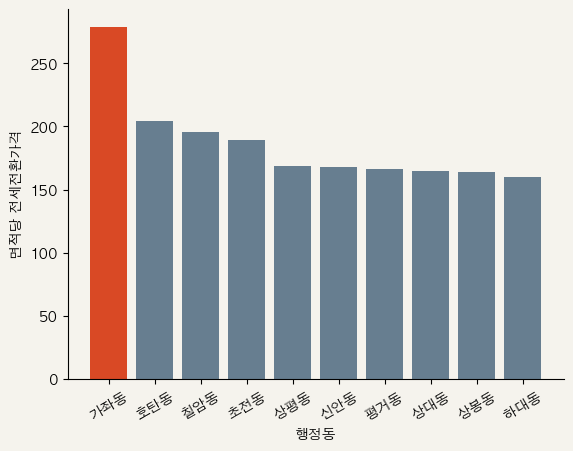

In [42]:
fig = plt.figure(facecolor="#F5F3ED")

plt.bar(data.행정동,
        data.price_per_m2,
        color = ["#D94925","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90"])


plt.gca().spines['right'].set_visible(False) #오른쪽 테두리 제거
plt.gca().spines['top'].set_visible(False) #위 테두리 제거

plt.gca().set_xlabel("행정동")
plt.gca().set_ylabel("면적당 전세전환가격")

# plt.yticks(ticks= []) #y축 tick 제거
plt.xticks(rotation= 30)
plt.gca().set_facecolor('#F5F3ED')


In [11]:
x = ["계약면적(㎡)","gnu_distance","건축년도","year","month","전월세구분_월세","도로조건","전월세구분_전세"]
y = [5476,4561,3682,2247,1672,1121,491,173]
data = pd.DataFrame(data = list(zip(x, y)), columns = ["features", "feature_importance"])

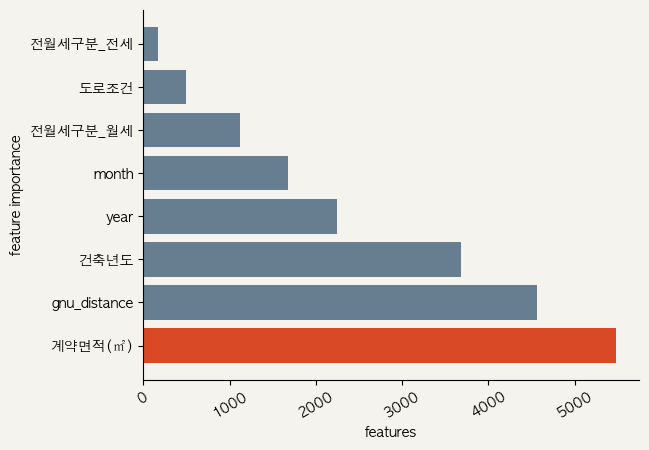

In [12]:
fig = plt.figure(facecolor="#F5F3ED")

plt.barh(data.features,
        data.feature_importance,
        color = ["#D94925","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90","#677E90"])


plt.gca().spines['right'].set_visible(False) #오른쪽 테두리 제거
plt.gca().spines['top'].set_visible(False) #위 테두리 제거

plt.gca().set_xlabel("features")
plt.gca().set_ylabel("feature importance")

# plt.yticks(ticks= []) #y축 tick 제거
plt.xticks(rotation= 30)
plt.gca().set_facecolor('#F5F3ED')


In [39]:
x = ["Ridge", "Lasso", "ElasticNet", "RandomForest", "LightGBM", "XGBoost","catBoost"]
y = [0.5776, 0.5685, 0.5232, 0.7936, 0.7992, 0.7582, 0.7976]
data = pd.DataFrame(data = list(zip(x, y)), columns = ["features", "score"])

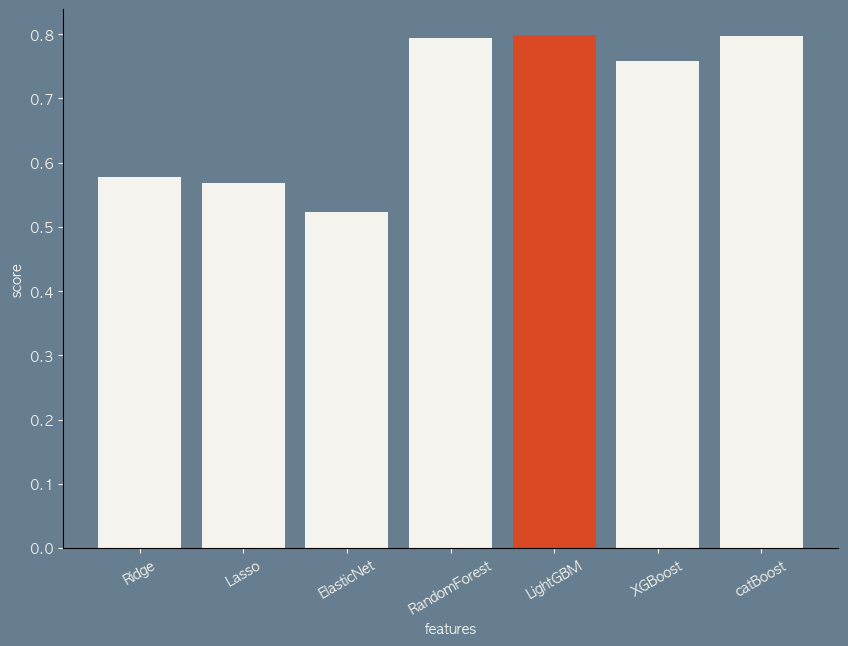

In [43]:

fig, ax = plt.subplots(figsize=(10,7), facecolor="#677E90")

plt.bar(data.features,
        data.score,
        color = ["#F5F3ED","#F5F3ED","#F5F3ED","#F5F3ED","#D94925","#F5F3ED","#F5F3ED","#F5F3ED","#F5F3ED","#677E90"])


plt.gca().spines['right'].set_visible(False) #오른쪽 테두리 제거
plt.gca().spines['top'].set_visible(False) #위 테두리 제거

plt.gca().set_xlabel("features", color="#F5F3ED")
plt.gca().set_ylabel("score", color="#F5F3ED")

# plt.yticks(ticks= []) #y축 tick 제거
plt.xticks(rotation= 30)

ax.tick_params(colors = "#F5F3ED")


plt.gca().set_facecolor('#677E90')